 Exploratory Data Analysis

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

In [ ]:
# Load data
df_complete = pd.read_csv('../owid-covid-data.csv')

# Number of countries
print("There are ", len(df_complete['country'].unique()), " distinct countries in the dataset before preprocessing")

After reviewing the data documentation provided by the data provider, we notice that some important variables — e.g. testing data — stop being recorded partway through the time period. Therefore, we subset the dataset to only retain dates where all variables of interest are consistently recorded.

In [19]:
# Columns that are completely NA
cols_NA = df_complete.columns[df_complete.isna().all()].tolist()
print(cols_NA)

df = df_complete.drop(columns=cols_NA)

# Find the last valid (non-NA) index for each column
last_valid = df.apply(lambda col: col.last_valid_index())
cutoff_date = df.loc[last_valid.values, 'date'].min()

print("Cutoff date:", cutoff_date)

# Subset dataset up to that cutoff_date
df = df[df['date'] <= cutoff_date]

['human_development_index']
Cutoff date: 2022-05-19


In [ ]:
# Basic info
print(df.info(verbose=True, show_counts=True))

# Number of NA for each column by country
df.groupby('country').apply(lambda x: x.isna().sum())

<class 'pandas.DataFrame'>
Index: 223663 entries, 0 to 569230
Data columns (total 60 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   country                                     223663 non-null  str    
 1   date                                        223663 non-null  str    
 2   total_cases                                 215883 non-null  float64
 3   new_cases                                   215859 non-null  float64
 4   new_cases_smoothed                          214624 non-null  float64
 5   total_cases_per_million                     215883 non-null  float64
 6   new_cases_per_million                       215859 non-null  float64
 7   new_cases_smoothed_per_million              214624 non-null  float64
 8   total_deaths                                215883 non-null  float64
 9   new_deaths                                  215869 non-null  float64
 10  new_deaths_s

,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,new_deaths_smoothed,...,continent,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand
country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,3,3,8,3,3,8,3,3,8,...,0,0,0,0,0,0,870,0,0,0
Africa,0,0,0,5,0,0,5,0,0,5,...,867,0,0,0,0,867,867,867,867,867
Albania,0,3,3,8,3,3,8,3,3,8,...,0,0,0,0,0,0,0,0,870,0
Algeria,0,3,3,8,3,3,8,3,3,8,...,0,0,0,0,0,0,0,0,0,0
American Samoa,0,0,0,5,0,0,5,0,0,5,...,0,0,0,0,0,867,867,0,867,867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
World excl. China and South Korea,0,0,0,5,0,0,5,0,0,5,...,867,867,867,867,867,867,867,867,867,867
"World excl. China, South Korea, Japan and Singapore",0,0,0,5,0,0,5,0,0,5,...,867,867,867,867,867,867,867,867,867,867
Yemen,0,3,3,8,3,3,8,3,3,8,...,0,0,0,0,0,870,0,0,0,0


We can see that some countries have an outstanding number of missing values in socioeconomic and demographic covariates, and therefore it may be worth considering excluding those countries later.

The data provider has already grouped the variables into categories i.e. *Confirmed cases*, *Confirmed deaths*, *Excess mortality*, *Hospital & ICU*, *Policy responses*, *Tests & positivity*, *Vaccinations*, *Others (socialeconomics & demographical covariates)*. We now look into variables by category.

For *confirmed cases* and *confirmed deaths*, the variables are various variants of the number of reported cases and deaths after scaling or smoothing. We first get a sense of the data distribution by plotting the trend of the raw data.

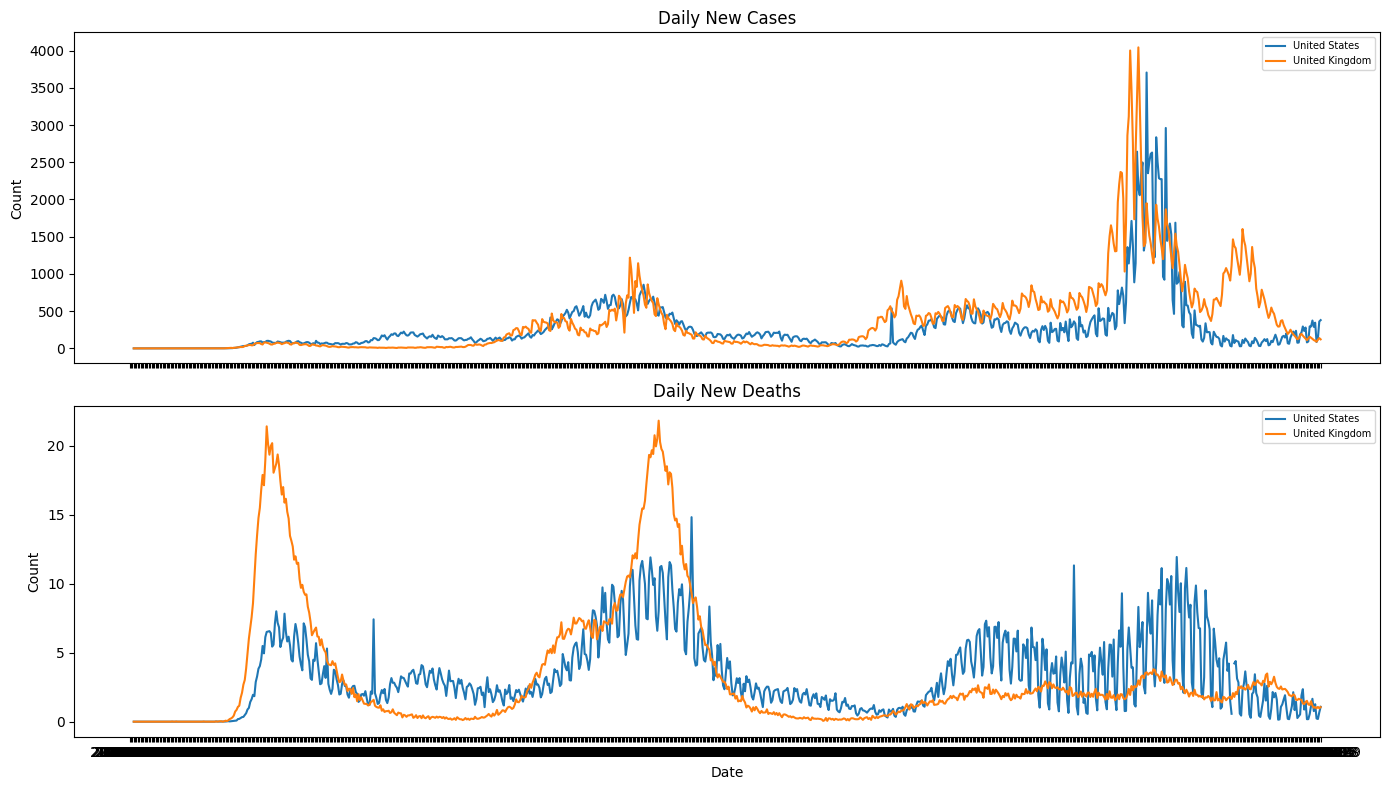

In [37]:
# Confirmed cases and confirmed death for selected countries
countries = ['United States', 'United Kingdom']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for country in countries:
    subset = df[df['country'] == country]
    axes[0].plot(subset['date'], subset['new_cases_per_million'], label=country)
    axes[1].plot(subset['date'], subset['new_deaths_per_million'], label=country)

axes[0].set_title('Daily New Cases')
axes[1].set_title('Daily New Deaths')

for ax in axes:
    ax.legend(fontsize=7)
    ax.set_ylabel('Count')

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

On one hand, we observe abnormal spikes in the raw data, which is an intrinsic property of daily reported figures due to delayed or incorrect reporting. To address this, we focus on variants that apply 7-day smoothing — taking the average over a 7-day window — to reduce such spikes.


We also observe large differences in scale across countries, suggesting the need to account for population size. Therefore, we choose the variant that normalizes the data to counts per million people.

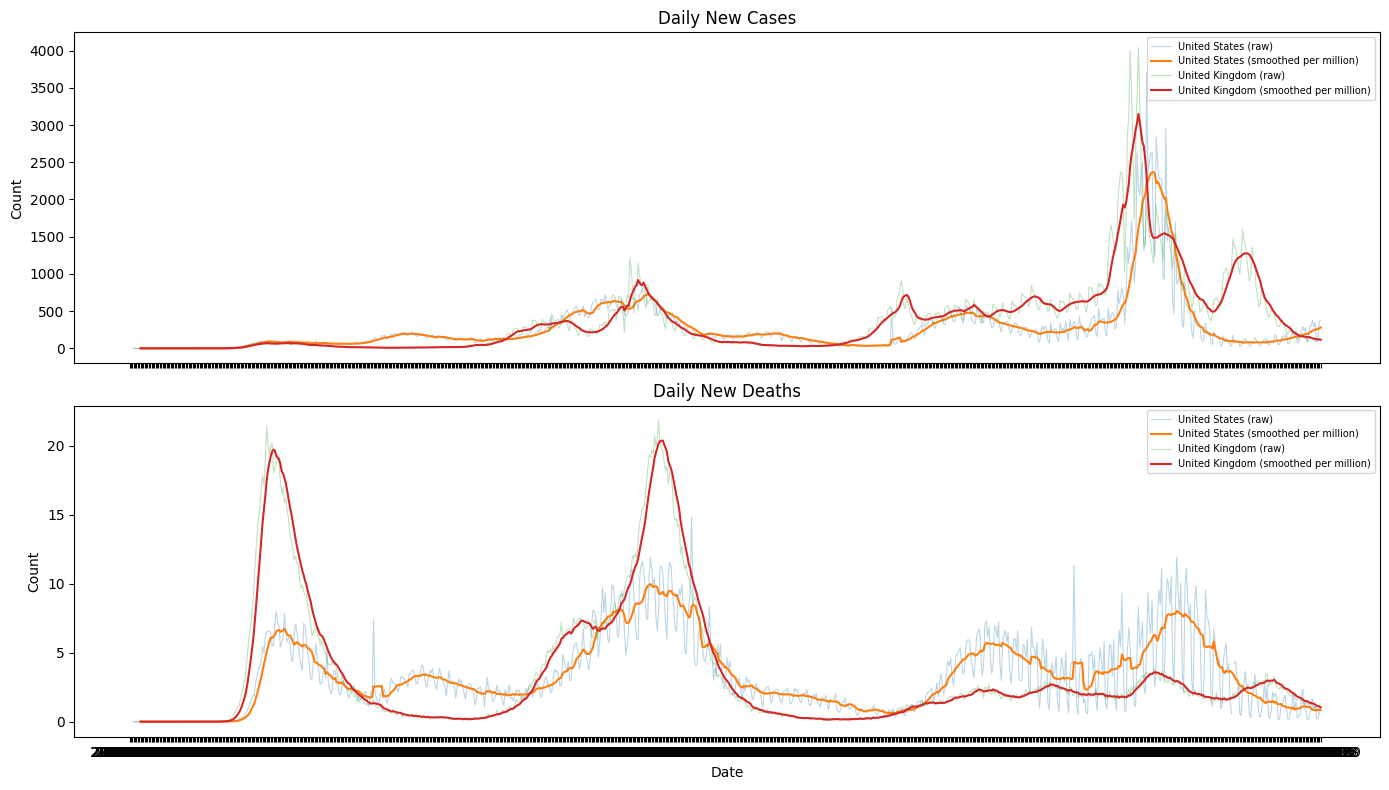

In [38]:
# Justify 7-day smoothing
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for country in countries:
    subset = df[df['country'] == country]
    
    # Raw data (lighter, thinner)
    axes[0].plot(subset['date'], subset['new_cases_per_million'], alpha=0.3, linewidth=0.8, label=f'{country} (raw)')
    axes[1].plot(subset['date'], subset['new_deaths_per_million'], alpha=0.3, linewidth=0.8, label=f'{country} (raw)')
    
    # Smoothed per million (bold, on top)
    axes[0].plot(subset['date'], subset['new_cases_smoothed_per_million'], linewidth=1.5, label=f'{country} (smoothed per million)')
    axes[1].plot(subset['date'], subset['new_deaths_smoothed_per_million'], linewidth=1.5, label=f'{country} (smoothed per million)')

axes[0].set_title('Daily New Cases')
axes[1].set_title('Daily New Deaths')

for ax in axes:
    ax.legend(fontsize=7)
    ax.set_ylabel('Count')

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

As discussed in a note in the data documentation, due to varying protocols and challenges in the attribution of the cause of death, the number of confirmed deaths may not accurately represent the true number of deaths caused by COVID-19. We refer to the idea in the paper (Karlinsky & Kobak, 2021) to correct the number of reported deaths using excess mortality available.

In [33]:
# Compute undercount ratio per country
undercount = (
    df.groupby('country')
    .apply(lambda x: x['excess_mortality_cumulative_per_million'].max() / 
                     x['new_deaths_smoothed_per_million'].sum())
    .reset_index()
    .rename(columns={0: 'undercount_ratio'})
)

df = df.merge(undercount, on='country')
df['new_deaths_smoothed_per_million_adjusted'] = df['new_deaths_smoothed_per_million'] * df['undercount_ratio']

/tmp/ipykernel_904298/1708846223.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  .apply(lambda x: x['excess_mortality_cumulative_per_million'].max() /


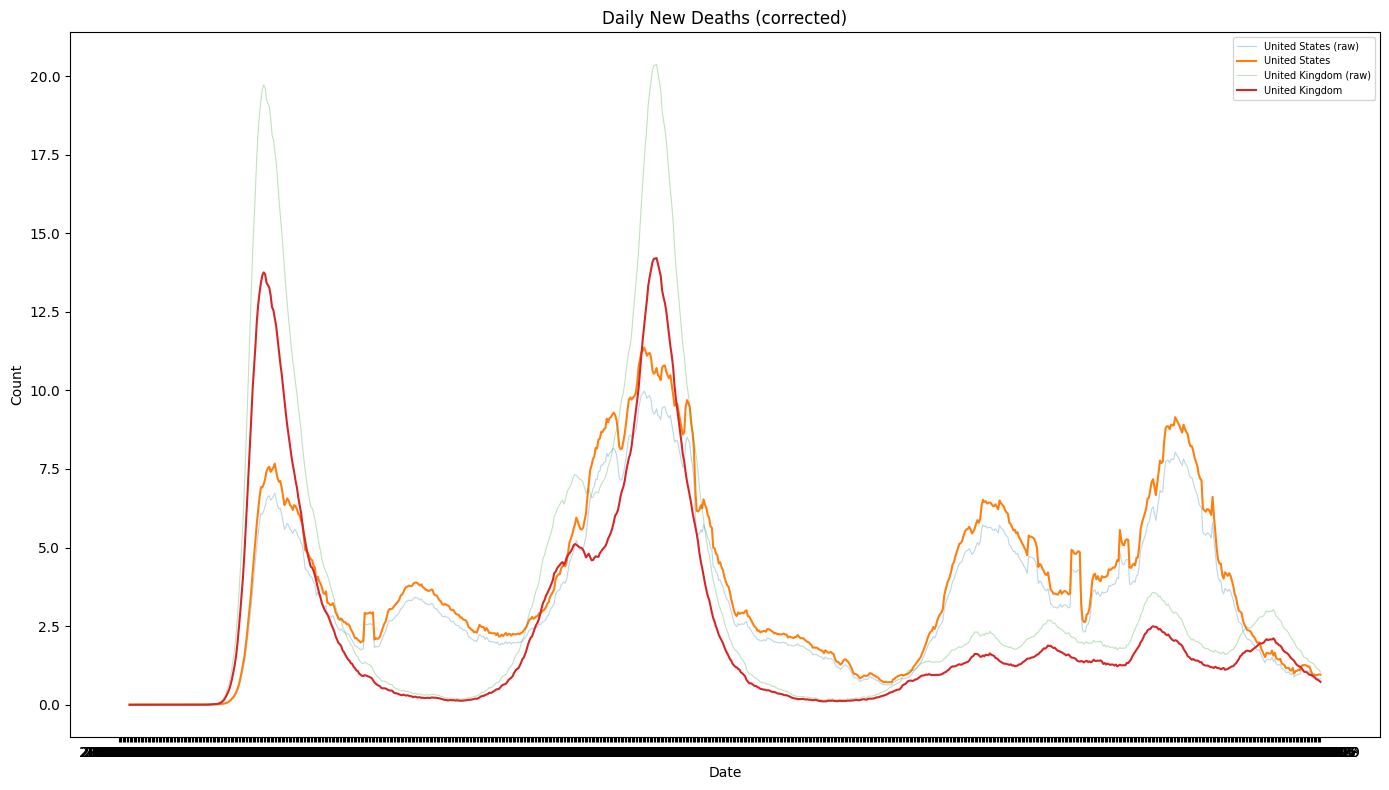

In [40]:
# Comparison after correction
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

for country in countries:
    subset = df[df['country'] == country]
    ax.plot(subset['date'], subset['new_deaths_smoothed_per_million'], alpha=0.3, linewidth=0.8, label=f'{country} (raw)')
    ax.plot(subset['date'], subset['new_deaths_smoothed_per_million_adjusted'], linewidth=1.5, label=country)

ax.set_title('Daily New Deaths (corrected)')
ax.legend(fontsize=7)
ax.set_ylabel('Count')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

We can see that the count for the UK is slightly downscaled while that is slightly upscaled for the USA, which is consistent with the result in the paper (Karlinsky & Kobak, 2021) where the estimated undercount ratio for the UK is 0.9 while that for the USA is 1.1.

For the socioeconomic and demographical covariates, it's important for them to be at least up to date so we exclude variables that are sourced from a much older dataset.


Given all the discussion, we complete preliminary variable selection and end up with the following variables of interest.

In [13]:
cols_of_interest = ['new_cases_smoothed_per_million', 'new_deaths_smoothed_per_million', 'excess_mortality',
                    'icu_patients_per_million', 'hosp_patients_per_million',
                    'stringency_index',
                    'new_tests_smoothed_per_thousand', 'tests_per_case',
                    'new_people_vaccinated_smoothed_per_hundred', 'people_fully_vaccinated_per_hundred',
                    'country', 'date', 'population_density', 'gdp_per_capita', 'extreme_poverty', 'handwashing_facilities', 'hospital_beds_per_thousand', 'life_expectancy', 'human_development_index']

df = df_complete[cols_of_interest]
# Basic info
print(df.info(verbose=True, show_counts=True))

<class 'pandas.DataFrame'>
RangeIndex: 570606 entries, 0 to 570605
Data columns (total 19 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   new_cases_smoothed_per_million              553109 non-null  float64
 1   new_deaths_smoothed_per_million             554131 non-null  float64
 2   excess_mortality                            13806 non-null   float64
 3   icu_patients_per_million                    39116 non-null   float64
 4   hosp_patients_per_million                   40656 non-null   float64
 5   stringency_index                            202760 non-null  float64
 6   new_tests_smoothed_per_thousand             103965 non-null  float64
 7   tests_per_case                              100650 non-null  float64
 8   new_people_vaccinated_smoothed_per_hundred  202840 non-null  float64
 9   people_fully_vaccinated_per_hundred         77011 non-null   float64
 10  country

We now look into variables by category

